In [140]:
#!pip install lightgbm


In [141]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import (
    mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score
)

In [142]:

df = pd.read_csv('Copia de data_merged.csv')



In [143]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [144]:
X = df.drop('popularity',axis=1)
y=df['popularity']

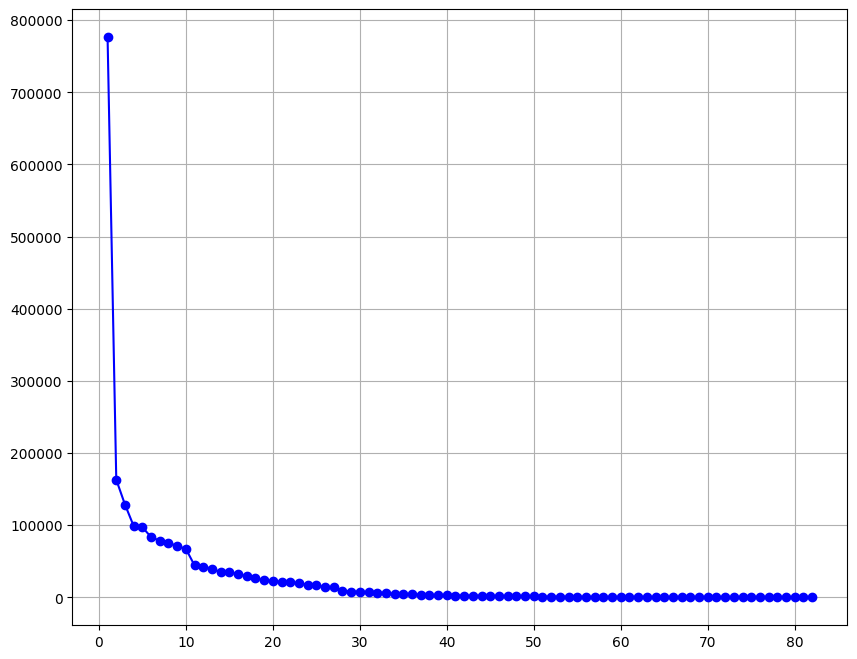

In [145]:

selector = SelectKBest(score_func=f_regression,k='all')
X_new = selector.fit_transform(X,y)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [146]:

selector = SelectKBest(score_func=f_regression,k=20)
X_new = selector.fit_transform(X,y)
select = selector.get_feature_names_out()
select

X = X[select]

In [147]:
X_train,X_test,y_train,y_test=train_test_split(X,y)

In [148]:
def compute_weight(y):
    weights = np.ones_like(y)

    weights[(y>=80)] =200
    weights[(y>=60)& (y<80)]=20
    weights[(y>=40)&(y<60)]=5
    return weights



y_train_log = np.log1p(y_train)

_weigths = compute_weight(y_train)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
train_data = lgb.Dataset(X_train_scaled,label=y_train_log,weight=_weigths)
params={
    'objetive':'regression',
    'metric':'mae',
    'learnig_rate':0.01,
    'max_depth':5,
    'num_leaves':20,
    'features_fraction':0.7,
    'verbosity':-1
}

model = lgb.train(params,train_data,num_boost_round=2000)
    

In [149]:
y_predict_log = model.predict(X_test_scaled)
y_pred = np.round(np.expm1(y_predict_log)).clip(0,100).astype(int)

In [150]:
mae = mean_absolute_error(y_test,y_pred)
mae

6.139277253936551

In [151]:
r2 = r2_score(y_test,y_pred)
r2


0.8206642469896521

In [152]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

9.273404370163586

In [153]:
mse = mean_squared_error(y_test,y_pred)
mse

85.99602861256909

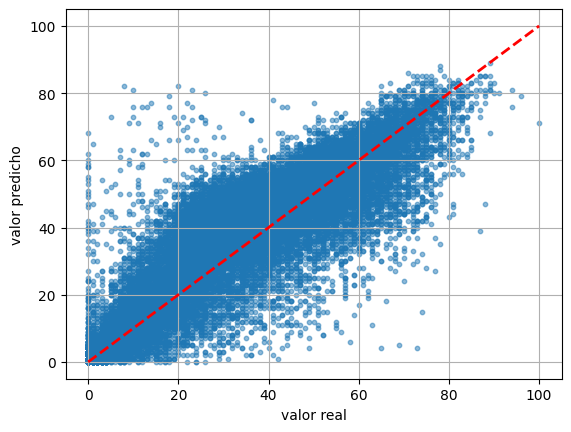

In [154]:
plt.scatter(y_test,y_pred,alpha=0.5,s=10)
plt.plot([0,100],[0,100],'r--',linewidth=2)
plt.xlabel('valor real')
plt.ylabel("valor predicho")
plt.grid()
plt.show()

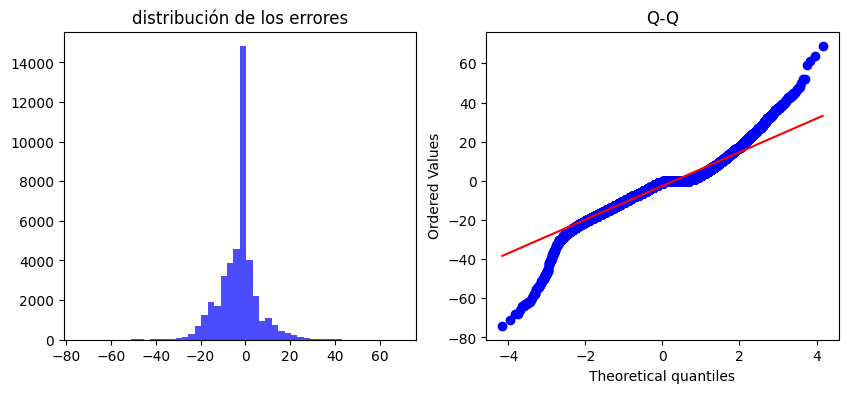

In [155]:
residual = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(residual,bins=50,alpha=0.7,color='blue')
plt.title("distribución de los errores")

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(residual,plot=plt)
plt.title("Q-Q")
plt.show()

stat_lf,p_value = stats.kstest(residual,'norm',args=(np.mean(residual),np.std(residual)))

In [156]:
print(f"p_valor: {p_value:.1f}")

p_valor: 0.0
